# Video Game Sales Analysis (1977–2018)
### What sells, and where? A regional look at 40 years of physical game sales

**Author:** Zac &nbsp;|&nbsp; **Tools:** Python (pandas, matplotlib), Tableau Public &nbsp;|&nbsp; **Data:** VGChartz via Maven Analytics Data Playground

---

## Project overview

This project analyzes worldwide video game sales to understand which games, genres and consoles drive sales, and how buying habits differ between North America, Europe and Japan. Before the analysis, the raw data is checked for quality problems, and each cleaning decision is documented with the evidence behind it.

### Business questions
1. **Which titles sold the most worldwide?**
2. **Which year had the highest sales? Is the industry growing over time?**
3. **Do any consoles specialize in a particular genre?**
4. **Which titles are popular in one region but flop in another?**

### Dataset
- **Source:** VGChartz (via Kaggle / Maven Analytics), license ODC-BY
- **Raw size:** 64,016 rows × 14 columns: title, console, genre, publisher, developer, critic score, release date, and sales in millions of copies (total, North America, Japan, Europe & Africa, rest of world)
- **After cleaning:** 18,766 rows covering 1977–2018

### Key findings (summary)
- **GTA V is the best-selling title (64.3M copies across 4 consoles).** Seven of the top 10 are *Call of Duty* games.
- **Physical sales peaked in 2008 (538M copies)** and then declined. This reflects the shift to digital downloads, not a shrinking industry.
- **Consoles have clear identities:** Xbox One and PS4 lean heavily on shooters, PC on simulation, and the Nintendo handhelds on casual and platform games.
- **Japan is a different market:** RPGs are 18.6% of Japanese sales versus about 5% in the West, while shooters barely sell there.

### Contents
1. Setup & first look
2. Data quality checks & cleaning
3. Q1: Best-selling titles
4. Q2: Sales over time
5. Q3: Console–genre specialization
6. Q4: Regional hits and flops
7. Conclusions & limitations
8. Export for Tableau

---
## 1. Setup & first look

Load the libraries and the raw data, then check its size, missing values and first rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("vgchartz-2024.csv")

print(df.shape)
print(df.isna().sum())
df.head()

(64016, 14)
img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


## 2. Data quality checks & cleaning

Each step below follows the same pattern: **check** for a possible problem, record the **finding**, then apply the **fix**.

### 2.1 How much data is missing?

In [2]:
# Percentage of missing values in each column
(df.isna().mean() * 100).round(1).sort_values(ascending=False)

critic_score    89.6
jp_sales        89.5
na_sales        80.3
pal_sales       80.0
other_sales     76.4
last_update     72.1
total_sales     70.4
release_date    11.0
img              0.0
title            0.0
console          0.0
genre            0.0
publisher        0.0
developer        0.0
dtype: float64

**Finding:** `total_sales` is missing in **70%** of rows. `critic_score` is missing in about 90% and `release_date` in 11%. The missing sales need a closer look before any analysis.

### 2.2 What do the rows without sales look like?

In [3]:
df[df["total_sales"].isna()][["title", "console", "total_sales", "release_date"]].head(10)

,title,console,total_sales,release_date
18922,God of War,Series,NaN,2005-03-22
18923,Warriors,Series,NaN,1997-06-30
18924,Devil May Cry,Series,NaN,2001-10-16
18925,God of War (2018),All,NaN,2018-04-20
18926,Dynasty Warriors,Series,NaN,1997-06-30
18927,God of War (2018),PS4,NaN,2018-04-20
18928,Frogger,Series,NaN,1981-10-23
18929,Uncharted 4: A Thief's End,PS4,NaN,2016-05-10
18930,Grand Theft Auto: San Andreas,PS2,NaN,2004-10-26
18931,God of War: Ragnarök,All,NaN,2022-11-09


In [4]:
# "Series" and "All" aren't real consoles, so how many of those are there?
print(df["console"].value_counts()[["Series", "All"]])
print("Of those, rows with sales:", df[df["console"].isin(["Series", "All"])]["total_sales"].notna().sum())

console
Series     464
All       1138
Name: count, dtype: int64
Of those, rows with sales: 0


**Finding:** many rows use **"Series"** or **"All"** as the console. These are franchise summary pages, not individual games: 1,602 rows, none with sales. The rest are titles VGChartz lists without tracking their sales.

**Fix:** keep only rows with sales data, and drop two columns not needed for the analysis (`img`, `last_update`).

In [5]:
sales = df.dropna(subset=["total_sales"]).copy()
sales = sales.drop(columns=["img", "last_update"])
print("Rows with sales data:", len(sales))   # 18,922

Rows with sales data: 18922


### 2.3 Do the years look complete?

In [6]:
sales["release_date"] = pd.to_datetime(sales["release_date"], errors="coerce")
sales["year"] = sales["release_date"].dt.year

print("Games with no release date:", sales["year"].isna().sum())
sales["year"].value_counts().sort_index().tail(8)

Games with no release date: 90


year
2013.0    514
2014.0    630
2015.0    640
2016.0    612
2017.0    689
2018.0    660
2019.0     35
2020.0     28
Name: count, dtype: int64

**Finding:** 2015 to 2018 each have 600+ games, then 2019 has **35** and 2020 has **28**. Data collection effectively stopped in 2018, even though the dataset says it covers up to 2024. Also, 90 games have no release date.

**Fix:** drop games with no release date and cut the timeline at 2018.

In [7]:
sales = sales.dropna(subset=["year"])
sales = sales[sales["year"] <= 2018]
sales["year"] = sales["year"].astype(int)

### 2.4 Are there duplicates?

In [8]:
print("Exact duplicate rows:", sales.duplicated().sum())
print("Same title + console twice:", sales.duplicated(["title", "console"]).sum())

sales[sales.duplicated(["title", "console"], keep=False)].sort_values("title")[
    ["title", "console", "publisher", "total_sales", "release_date"]].head(8)

Exact duplicate rows: 3
Same title + console twice: 60


,title,console,publisher,total_sales,release_date
12460,Adventure Time: The Secret of the Nameless Kin...,X360,Little Orbit,0.06,2014-10-18
17417,Adventure Time: The Secret of the Nameless Kin...,X360,Little Orbit,0.01,2014-11-18
13536,Akko ni Omakase! Brain Shock,DS,Taito,0.04,2006-12-07
13461,Akko ni Omakase! Brain Shock,DS,Taito,0.04,2006-12-07
5772,Assassin's Creed: Altair's Chronicles,DS,Ubisoft,0.27,2008-02-05
13258,Assassin's Creed: Altair's Chronicles,DS,Ubisoft,0.05,2008-02-05
18436,Battle of the Bands,Wii,THQ,0.00,2008-04-21
18413,Battle of the Bands,Wii,THQ,0.00,2008-04-21


**Finding:** **3** rows are exact copies. The other title + console repeats fall into two groups:
- **Most have different sales or release dates** (e.g. *Assassin's Creed: Altair's Chronicles*: 0.27M vs 0.05M), which suggests separate regional listings by VGChartz. These are kept.
- **A handful match on sales and date** but differ in a small detail, such as the developer name (*Akko ni Omakase!*: "Taito" vs "Taito Corporation"). These are likely the same game entered twice. They are very small sellers (under 0.15M each), so they're left in; the effect on results is negligible.

**Fix:** remove exact duplicates only.

In [9]:
sales = sales.drop_duplicates()

### 2.5 What does a missing regional sales value mean?

In [10]:
region_cols = ["na_sales", "jp_sales", "pal_sales", "other_sales"]
print(sales[region_cols].isna().sum())

# If missing means zero, the filled regions should add up to total_sales
diff = (sales[region_cols].fillna(0).sum(axis=1) - sales["total_sales"]).abs()
print("Max gap vs total:", round(diff.max(), 2))

na_sales        6150
jp_sales       12130
pal_sales       6005
other_sales     3712
dtype: int64
Max gap vs total: 0.02


**Finding:** with missing regional values filled as 0, the regions still add up to `total_sales` within **0.02M**, which is just rounding. So a blank means "no recorded sales in that region", not unknown data.

**Fix:** fill missing regional sales with 0.

In [11]:
sales[region_cols] = sales[region_cols].fillna(0)

### 2.6 How is each game represented?

In [12]:
sales[sales["title"] == "Grand Theft Auto V"][["title", "console", "total_sales"]]

,title,console,total_sales
0,Grand Theft Auto V,PS3,20.32
1,Grand Theft Auto V,PS4,19.39
3,Grand Theft Auto V,X360,15.86
28,Grand Theft Auto V,XOne,8.72


**Finding:** each row is **one game on one console**. GTA V has 4 rows (PS3, PS4, X360, XOne). The data doesn't need changing, but sales must be added up across consoles to rank titles (Q1).

### 2.7 Cleaning summary

In [13]:
print("Rows:", len(sales))
print("Years:", sales["year"].min(), "to", sales["year"].max())
print("Total copies (millions):", round(sales["total_sales"].sum(), 1))
print("Games rounding to 0.00M sales:", (sales["total_sales"] == 0).sum())

Rows: 18766
Years: 1977 to 2018
Total copies (millions): 6592.6
Games rounding to 0.00M sales: 1317


| Step | Decision | Rows remaining |
|---|---|---|
| Raw data | – | 64,016 |
| 2.2 | Keep rows with sales data | 18,922 |
| 2.3 | Drop missing dates, cut at 2018 | 18,769 |
| 2.4 | Remove exact duplicates | **18,766** |

About 1,300 games show **0.00M** total sales. They sold fewer than 10,000 copies and round down to zero. They are real sales, so they are kept.

---
## 3. Q1: Which titles sold the most worldwide?

**Approach:** rank the raw rows first to show why they mislead, then add sales up across consoles for the real ranking.

### 3.1 Naive ranking (one row per console)

In [14]:
# Top 10 rows as-is, where each row is one game on one console
sales.nlargest(10, "total_sales")[["title", "console", "total_sales"]]

,title,console,total_sales
0,Grand Theft Auto V,PS3,20.32
1,Grand Theft Auto V,PS4,19.39
2,Grand Theft Auto: Vice City,PS2,16.15
3,Grand Theft Auto V,X360,15.86
4,Call of Duty: Black Ops 3,PS4,15.09
5,Call of Duty: Modern Warfare 3,X360,14.82
6,Call of Duty: Black Ops,X360,14.74
7,Red Dead Redemption 2,PS4,13.94
8,Call of Duty: Black Ops II,X360,13.86
9,Call of Duty: Black Ops II,PS3,13.80


GTA V takes 3 of the top 10 spots and *Black Ops II* takes 2. This ranks **versions**, not **games**.

### 3.2 Correct ranking (all consoles combined)

In [15]:
top_titles = (
    sales.groupby("title")
         .agg(total_sales=("total_sales", "sum"),
              consoles=("console", "nunique"),
              publisher=("publisher", "first"),
              genre=("genre", "first"))
         .sort_values("total_sales", ascending=False)
)
top_titles.head(10)

,total_sales,consoles,publisher,genre
title,,,,
Grand Theft Auto V,64.29,4,Rockstar Games,Action
Call of Duty: Black Ops,30.99,5,Activision,Shooter
Call of Duty: Modern Warfare 3,30.71,4,Activision,Shooter
Call of Duty: Black Ops II,29.59,4,Activision,Shooter
Call of Duty: Ghosts,28.80,6,Activision,Shooter
Call of Duty: Black Ops 3,26.72,5,Activision,Shooter
Call of Duty: Modern Warfare 2,25.02,3,Activision,Shooter
Minecraft,24.01,7,Sony Computer Entertainment,Misc
Grand Theft Auto IV,22.53,3,Rockstar Games,Action


### 3.3 Where is Nintendo?

The top 10 has no Nintendo games, even though *Wii Sports* and *Mario Kart Wii* are some of the best-selling games of all time. Checking the raw data:

In [16]:
# Famous Nintendo hits: are they in the data?
df[df["title"].isin(["Wii Sports", "Mario Kart Wii", "Wii Sports Resort"])][
    ["title", "console", "publisher", "total_sales"]]

,title,console,publisher,total_sales
45686,Mario Kart Wii,Wii,Nintendo,NaN
57892,Wii Sports,Wii,Nintendo,NaN
57894,Wii Sports Resort,Wii,Nintendo,NaN


In [17]:
nintendo = df[df["publisher"] == "Nintendo"]
print("Nintendo titles listed:", len(nintendo))
print("Nintendo titles WITH sales data:", nintendo["total_sales"].notna().sum())

Nintendo titles listed: 1476
Nintendo titles WITH sales data: 384


### Q1 Findings

- **GTA V is the best-selling title: 64.3M copies** across 4 consoles, more than double the #2 game.
- **Call of Duty dominates:** 7 of the top 10 titles are *Call of Duty* games (21.8M–31.0M each).
- The rest of the top 10 is *Minecraft* (24.0M) and *GTA IV* (22.5M).

> **⚠️ Data limitation: missing Nintendo sales**
>
> Nintendo's biggest hits **are listed, but their sales are blank**. Only **384 of 1,476** Nintendo titles (about 26%) have sales figures. As a result:
> - The rankings mostly reflect **third-party publishers** (Rockstar, Activision, etc.).
> - **Nintendo consoles** (Wii, DS, GBA) look smaller than they really were, and their genre profiles are incomplete.
> - **Japan** is under-counted, since Nintendo is especially strong there.
>
> All findings below should be read with this gap in mind.

*Note: the `publisher` and `genre` columns show the label from one version of each game (for example, Minecraft shows Sony because the PlayStation version comes first).*

---
## 4. Q2: Which year had the highest sales? Is the industry growing?

**Approach:** total sales and number of games per year, charted separately because they're on different scales.

In [18]:
yearly = (
    sales.groupby("year")
         .agg(total_sales=("total_sales", "sum"),
              games=("title", "count"))
         .assign(sales_per_game=lambda d: d["total_sales"] / d["games"])
)

print("Best year:", yearly["total_sales"].idxmax(),
      "with", round(yearly["total_sales"].max(), 1), "M copies")
yearly.round(2).tail(12)

Best year: 2008 with 538.1 M copies


,total_sales,games,sales_per_game
year,,,
2007,436.39,1268,0.34
2008,538.09,1625,0.33
2009,495.36,1753,0.28
2010,454.02,1381,0.33
2011,440.32,1252,0.35
2012,285.47,694,0.41
2013,266.00,514,0.52
2014,292.11,630,0.46
2015,230.45,640,0.36


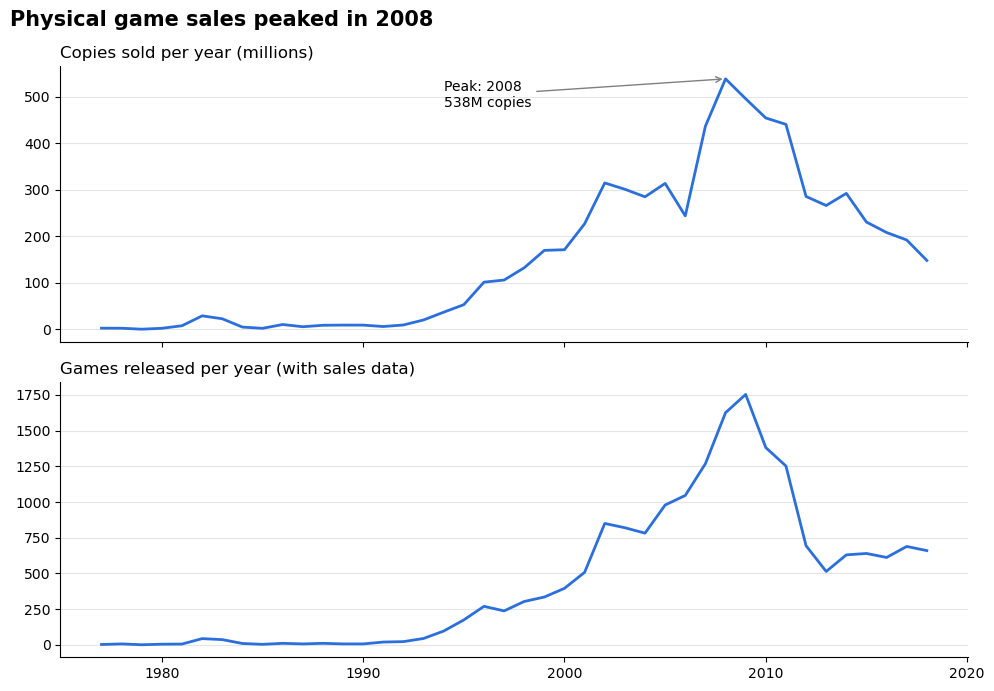

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(yearly.index, yearly["total_sales"], color="#2a6fdb", linewidth=2)
axes[0].set_title("Copies sold per year (millions)", loc="left", fontsize=12)

peak = yearly["total_sales"].idxmax()
axes[0].annotate(f"Peak: {peak}\n{yearly.loc[peak, 'total_sales']:.0f}M copies",
                 xy=(peak, yearly.loc[peak, "total_sales"]),
                 xytext=(peak - 14, yearly.loc[peak, "total_sales"] - 60),
                 arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10)

axes[1].plot(yearly.index, yearly["games"], color="#2a6fdb", linewidth=2)
axes[1].set_title("Games released per year (with sales data)", loc="left", fontsize=12)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e5e5")

fig.suptitle("Physical game sales peaked in 2008", fontsize=15,
             x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

### Q2 Findings

- **2008 was the peak year: 538M copies.** Sales grew fast from the mid-1990s (PlayStation era) through the Wii / Xbox 360 / PS3 boom, then fell to 148M by 2018.
- **The industry is almost certainly *not* shrinking.** VGChartz mainly tracks **physical** copies. After 2011, digital downloads (Steam, PlayStation Store, Xbox Store) took off, and those sales aren't counted here. The global games market kept growing over the same period, so this chart shows the **decline of physical retail**, not of gaming.
- **Supporting evidence:** the number of games tracked also fell sharply after 2011 (from about 1,750 in 2009 to 500–700), which suggests fewer releases were tracked, not that fewer were made.

---
## 5. Q3: Do any consoles specialize in a particular genre?

**Approach:** for the 12 biggest consoles and 10 biggest genres, calculate what share of each console's sales comes from each genre. Then compare each share with the market average to get a specialization score.

### 5.1 Genre share of each console's sales

In [20]:
# Focus on the 12 biggest consoles and 10 biggest genres to keep it readable
top_consoles = sales.groupby("console")["total_sales"].sum().nlargest(12).index
top_genres = sales.groupby("genre")["total_sales"].sum().nlargest(10).index

sub = sales[sales["console"].isin(top_consoles) & sales["genre"].isin(top_genres)]

share = pd.crosstab(sub["console"], sub["genre"],
                    values=sub["total_sales"], aggfunc="sum",
                    normalize="index").fillna(0) * 100
share = share.loc[top_consoles, top_genres]   # biggest first, in both directions

share.round(0)

genre,Sports,Action,Shooter,Misc,Racing,Role-Playing,Platform,Fighting,Adventure,Simulation
console,,,,,,,,,,
PS2,26.0,17.0,10.0,9.0,13.0,4.0,6.0,7.0,4.0,4.0
X360,17.0,20.0,28.0,7.0,8.0,8.0,2.0,5.0,3.0,1.0
PS3,19.0,24.0,24.0,7.0,6.0,7.0,3.0,6.0,3.0,1.0
PS,23.0,15.0,7.0,8.0,15.0,6.0,5.0,11.0,6.0,3.0
PS4,23.0,19.0,31.0,3.0,4.0,10.0,3.0,3.0,2.0,1.0
Wii,22.0,15.0,5.0,29.0,6.0,1.0,4.0,3.0,8.0,7.0
DS,8.0,16.0,2.0,17.0,3.0,8.0,6.0,2.0,16.0,22.0
XOne,20.0,19.0,38.0,4.0,6.0,6.0,2.0,2.0,2.0,1.0
PSP,19.0,21.0,9.0,5.0,15.0,10.0,7.0,6.0,8.0,3.0


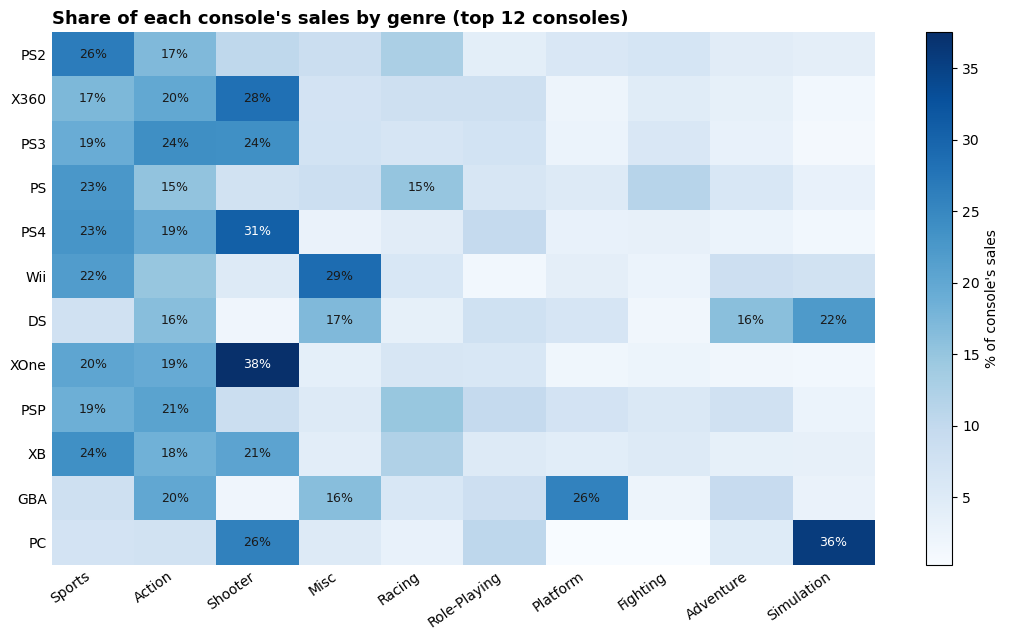

In [21]:
fig, ax = plt.subplots(figsize=(11, 6.5))
im = ax.imshow(share.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(share.columns)), share.columns, rotation=35, ha="right")
ax.set_yticks(range(len(share.index)), share.index)

# Label only the strong cells (15%+) so the chart isn't cluttered
for i in range(share.shape[0]):
    for j in range(share.shape[1]):
        v = share.iloc[i, j]
        if v >= 15:
            ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                    color="white" if v >= 30 else "#1a1a1a")

ax.set_title("Share of each console's sales by genre (top 12 consoles)",
             loc="left", fontsize=13, fontweight="bold")
fig.colorbar(im, ax=ax, label="% of console's sales")
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

### 5.2 Specialization score

A score of **1.0** means a genre's share on that console matches the market average; **2.0** means twice the average.

In [22]:
# 1.0 = same as the market average, 2.0 = twice the average
overall = sub.groupby("genre")["total_sales"].sum() / sub["total_sales"].sum() * 100
lift = share / overall[top_genres]

# Each console's most over-represented genre
pd.DataFrame({
    "top_genre": lift.idxmax(axis=1),
    "times_market_avg": lift.max(axis=1).round(1)
}).sort_values("times_market_avg", ascending=False)

,top_genre,times_market_avg
console,,
PC,Simulation,7.2
GBA,Platform,5.3
DS,Simulation,4.5
Wii,Misc,3.0
PS,Fighting,2.2
XOne,Shooter,2.2
PS4,Shooter,1.8
X360,Shooter,1.7
PSP,Racing,1.7


### Q3 Findings

Yes, several consoles clearly specialize:

- **Shooters dominate the modern consoles, led by Xbox.** Shooters are 38% of Xbox One sales, 31% of PS4 and 28% of Xbox 360, versus 17% market-wide, driven by *Call of Duty*, *Battlefield* and *Halo*. Xbox One leans on them the most (2.2× the market average).
- **PC is the simulation platform.** 36% of PC sales are Simulation, about **7×** the market average (*The Sims*, city builders, flight sims).
- **Nintendo handhelds and the Wii lean casual.** The GBA over-indexes on Platformers (**5.3×**), the DS on Simulation (**4.5×**) and Adventure, and the Wii on "Misc" party and fitness games (**3.0×**).
- **Older PlayStations are the generalists.** PS2, PS3 and PSP are spread fairly evenly across Sports, Action, Shooters and Racing, with no genre above 1.7× the market average.

*Caveat: because many Nintendo first-party titles have no sales data, the Wii, DS and GBA profiles mostly reflect third-party games.*

---
## 6. Q4: Which titles are popular in one region but flop in another?

**Approach:** first compare genre tastes across regions (big picture), then check the data for regional tracking problems, and finally find individual games that sold mostly in one region.

### 6.1 How big is each region?

In [23]:
region_cols = ["na_sales", "jp_sales", "pal_sales", "other_sales"]
(sales[region_cols].sum() / sales["total_sales"].sum() * 100).round(1)

na_sales       50.7
jp_sales       10.3
pal_sales      29.0
other_sales     9.9
dtype: float64

North America is about half of all tracked sales, Europe & Africa 29%, Japan 10%.

### 6.2 Genre tastes by region

In [24]:
genre_region = sales.groupby("genre")[["na_sales", "jp_sales", "pal_sales"]].sum()
genre_share = (genre_region / genre_region.sum() * 100).round(1)
genre_share.sort_values("jp_sales", ascending=False).head(12)

,na_sales,jp_sales,pal_sales
genre,,,
Role-Playing,5.1,18.6,4.7
Sports,18.2,16.0,17.8
Action,17.6,11.7,17.9
Fighting,5.2,8.6,4.2
Misc,8.8,8.2,7.7
Adventure,4.7,6.7,4.8
Strategy,1.4,5.4,1.4
Simulation,4.6,5.3,4.5
Shooter,15.8,5.0,17.0


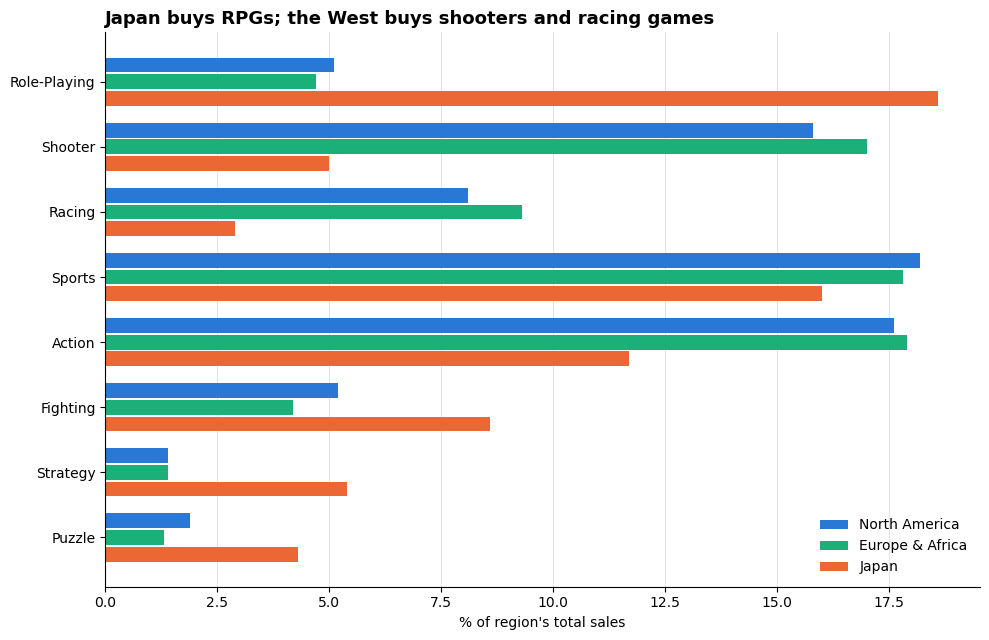

In [25]:
import numpy as np

genres = ["Role-Playing", "Shooter", "Racing", "Sports",
          "Action", "Fighting", "Strategy", "Puzzle"]
plot_df = genre_share.loc[genres[::-1]]   # reversed so Role-Playing ends up on top

labels = {"na_sales": "North America", "pal_sales": "Europe & Africa", "jp_sales": "Japan"}
colors = {"na_sales": "#2a78d6", "pal_sales": "#1baf7a", "jp_sales": "#eb6834"}

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(plot_df))
h = 0.26
for k, col in enumerate(["na_sales", "pal_sales", "jp_sales"]):
    ax.barh(y + (1 - k) * h, plot_df[col], height=h - 0.03,
            color=colors[col], label=labels[col])

ax.set_yticks(y, plot_df.index)
ax.set_xlabel("% of region's total sales")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e5e5e5")
ax.set_axisbelow(True)
ax.set_title("Japan buys RPGs; the West buys shooters and racing games",
             loc="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.3 Checking regional data quality

A first pass at the game-level comparison surfaced suspicious results, like *"SpongeBob's Truth or Square (US sales)"* as a top North American favorite and *The Sims* expansions selling 99% in North America. Two checks:

**Check A: titles with partial-tracking notes**

In [26]:
flagged = sales[sales["title"].str.contains("sales)", case=False, regex=False)]
print("Rows with partial-tracking notes:", len(flagged))
print("Copies involved (millions):", round(flagged["total_sales"].sum(), 1))
flagged[["title", "console", "na_sales", "jp_sales", "pal_sales"]].head(10)

Rows with partial-tracking notes: 176
Copies involved (millions): 43.3


,title,console,na_sales,jp_sales,pal_sales
392,Mortal Kombat II (US & Others sales),GEN,1.78,0.00,0.53
422,Star Wars Battlefront II (US sales),PS2,2.18,0.00,0.07
575,Medal of Honor: European Assault (All Region s...,PS2,0.89,0.09,0.69
713,NBA Live 06 (All region sales),PS2,1.44,0.00,0.15
729,Tony Hawk's American Wasteland (Old all region...,PS2,0.80,0.01,0.63
737,Midnight Club 3: DUB Edition (America/Others S...,PS2,1.30,0.00,0.23
866,Tony Hawk's American Wasteland (Weekly america...,PS2,1.38,0.00,0.05
897,NBA Live 06 (Weekly american sales),PS2,1.35,0.00,0.05
997,Ratchet & Clank: Up Your Arsenal (Weekly ameri...,PS2,1.27,0.00,0.05
1049,Midnight Club 3: DUB Edition (America weekly s...,PS2,1.22,0.00,0.05


**Finding:** 176 rows (43.3M copies) have notes like "(US sales)" or "(JP sales)" in the title, meaning only one region was tracked.

**Check B: is PC regional data reliable?**

In [27]:
pc = sales[sales["console"] == "PC"]
print(pc[region_cols].sum().round(1))

# Sales by 5-year period: does the NA/Europe split jump around?
pc.groupby(pc["year"] // 5 * 5)[["na_sales", "pal_sales"]].sum().round(1)

na_sales       58.3
jp_sales        0.0
pal_sales      95.8
other_sales    13.5
dtype: float64


,na_sales,pal_sales
year,,
1985,0.0,0.0
1990,3.3,2.3
1995,13.1,4.9
2000,14.0,10.0
2005,4.4,27.7
2010,19.4,41.4
2015,4.1,9.5


**Finding:** PC has **zero** Japan sales, and the North America vs Europe split flips between periods. That points to tracking changes, not real buying habits.

**Fix:** exclude flagged rows and PC from the game-level regional comparison. Genre-level results (6.2) are barely affected, since the flagged rows are under 1% of sales.

In [28]:
sales["partial_tracking"] = sales["title"].str.contains("sales)", case=False, regex=False)
regional = sales[~sales["partial_tracking"] & (sales["console"] != "PC")]
print("Rows used for regional title analysis:", len(regional))

Rows used for regional title analysis: 17044


### 6.4 Japan-only hits (1M+ copies, 80%+ sold in Japan)

In [29]:
by_title = regional.groupby("title")[["total_sales", "na_sales", "jp_sales", "pal_sales"]].sum()
by_title = by_title[by_title["total_sales"] >= 1]          # only real hits

for r in ["na", "jp", "pal"]:
    by_title[f"{r}_share"] = (by_title[f"{r}_sales"] / by_title["total_sales"] * 100).round(1)

jp_only = by_title[by_title["jp_share"] >= 80].sort_values("jp_sales", ascending=False)
print("Japan-only hits:", len(jp_only))
jp_only.head(10)

Japan-only hits: 35


,total_sales,na_sales,jp_sales,pal_sales,na_share,jp_share,pal_share
title,,,,,,,
R.B.I. Baseball,2.20,0.15,2.05,0.0,6.8,93.2,0.0
Famista '89 - Kaimaku Han!!,2.05,0.00,2.05,0.0,0.0,100.0,0.0
Dragon Quest XI,1.82,0.00,1.82,0.0,0.0,100.0,0.0
Tomodachi Collection: New Life,1.69,0.00,1.69,0.0,0.0,100.0,0.0
Super Puyo Puyo,1.70,0.00,1.69,0.0,0.0,99.4,0.0
Ninja Hattori Kun: Ninja wa Shuugyou Degogiru no Maki,1.50,0.00,1.50,0.0,0.0,100.0,0.0
Dragon Ball Z,1.45,0.00,1.45,0.0,0.0,100.0,0.0
Game de Hakken!! Tamagotchi 2,1.45,0.00,1.44,0.0,0.0,99.3,0.0
Tamagotchi,1.45,0.00,1.44,0.0,0.0,99.3,0.0


### 6.5 Western hits that flopped in Japan (under 50k copies there)

In [30]:
west_only = by_title[by_title["jp_sales"] < 0.05].sort_values("total_sales", ascending=False)
print("Hits with almost no Japan sales:", len(west_only))
west_only.head(10)

Hits with almost no Japan sales: 1008


,total_sales,na_sales,jp_sales,pal_sales,na_share,jp_share,pal_share
title,,,,,,,
Guitar Hero III: Legends of Rock,16.36,11.12,0.04,2.57,68.0,0.2,15.7
Call of Duty: World at War,15.76,9.36,0.00,4.58,59.4,0.0,29.1
LEGO Star Wars: The Complete Saga,15.33,8.95,0.00,4.82,58.4,0.0,31.4
LEGO Batman: The Videogame,13.46,7.63,0.00,3.92,56.7,0.0,29.1
LEGO Indiana Jones: The Original Adventures,11.89,6.75,0.00,3.16,56.8,0.0,26.6
Star Wars: The Force Unleashed,10.07,5.28,0.01,2.90,52.4,0.1,28.8
Guitar Hero: World Tour,10.00,6.20,0.00,2.18,62.0,0.0,21.8
Halo 4,9.96,6.72,0.04,2.36,67.5,0.4,23.7
FIFA Soccer 08,9.47,1.96,0.04,3.96,20.7,0.4,41.8


### 6.6 North America vs Europe favorites

In [31]:
by_title["na_minus_pal"] = by_title["na_share"] - by_title["pal_share"]
cols = ["total_sales", "na_share", "pal_share"]

print("Europe favorites:")
display(by_title.sort_values("na_minus_pal").head(6)[cols])
print("North America favorites:")
display(by_title.sort_values("na_minus_pal").tail(6)[cols])

Europe favorites:


,total_sales,na_share,pal_share
title,,,
Peppa Pig: The Game,1.25,0.0,92.0
Brian Lara Cricket,1.26,1.6,89.7
TOCA 2 Touring Car Championship,1.32,2.3,87.9
Colin McRae Rally,2.87,3.1,84.7
SingStar Party,1.35,0.0,77.0
SingStar Rocks!,1.10,0.0,76.4


North America favorites:


,total_sales,na_share,pal_share
title,,,
NERF N-Strike Elite,1.00,93.0,0.0
The Price is Right,1.31,93.1,0.0
Madden NFL 2000,2.36,95.8,2.5
Madden NFL 98,1.35,95.6,2.2
Wipeout 2,1.21,93.4,0.0
NCAA Football 12,1.83,94.0,0.0


### Q4 Findings

**Japan is a different market.**

- **RPGs are Japan's #1 genre** (18.6% of sales), almost 4× their share in the West. Shooters (5%) and racing games (2.9%) barely sell there.
- **35 hits sold 80%+ of their copies in Japan alone**, e.g. *Tomodachi Collection*, *Super Puyo Puyo* and *Famista '89*.
- **1,008 million-sellers sold almost nothing in Japan** (under 50k copies), including *Guitar Hero III* (16.4M worldwide), *Call of Duty: World at War* (15.8M) and *Halo 4* (10.0M).

**North America and Europe are similar, except for local tastes:**

- **Europe:** rally and touring-car racing (*Colin McRae Rally*, *TOCA 2*), cricket (*Brian Lara Cricket*), karaoke (*SingStar*) and *Peppa Pig*.
- **North America:** American football (*Madden NFL*, *NCAA Football*), TV game shows (*The Price is Right*, *Wipeout*) and *NERF*.

*Data decisions and caveats:*

- Excluded 176 rows whose titles contain tracking notes like "(US sales)" from the game-level regional comparison, because only one region was counted for them. (They remain in Q1–Q3, where they have almost no effect.)
- Excluded PC from the regional title comparison: it has zero Japan sales and an inconsistent North America/Europe split over time, which suggests tracking changes. This drops genuinely European PC hits like *Football Manager*.
- Some titles are filed under a name from another region. *R.B.I. Baseball* appears as a "Japan hit" because the Japanese original's sales are filed under the US name.
- A 0 in a region can mean "never released there", not "flopped".
- Japan is under-counted because of the missing Nintendo data.

**Business takeaway:** a publisher localizing for Japan should prioritize RPGs and puzzle games, while a shooter or sports title needs a Western-first launch plan.

---
## 7. Conclusions & limitations

### Conclusions
1. **A few franchises dominate.** *GTA V* and *Call of Duty* take 8 of the top 10 spots.
2. **Physical sales peaked in 2008** and have fallen since, as buying shifted to digital downloads.
3. **Consoles have genre identities:** modern consoles (especially Xbox One) lean on shooters, PC on simulation, and Nintendo on casual and platform games, while older PlayStations are all-rounders.
4. **Regional tastes differ sharply:** Japan favors RPGs and local franchises, the West favors shooters and racing, and North America and Europe each have their own sports and TV-based hits.

### Business recommendations
- **Localizing for Japan:** prioritize RPGs and puzzle games. Shooters and racing games need a Western-first launch plan.
- **Platform strategy:** shooters should launch on Xbox and PlayStation first, and simulation titles should treat PC as the lead platform.

### Limitations
- **Physical sales only:** digital sales are not tracked, so recent years are under-counted.
- **Missing Nintendo data:** only 26% of Nintendo titles have sales figures.
- **Coverage ends in 2018,** despite the "1971–2024" label.
- **Title naming:** some games are filed under another region's name or split across two titles (e.g. *Dragon Quest XI*).
- **Only 30% of listed titles have sales data**, so results describe the tracked games, not the full market.

---
## 8. Export for Tableau

Two files for the Tableau Public dashboard:
- `vg_sales_clean.csv`: the full clean dataset (one row per game per console)
- `vg_sales_by_region.csv`: regional sales in "long" format (one row per game per region), so Region can be used directly as a color or filter

In [33]:
# 1. Full clean dataset (one row per game per console)
sales.to_csv("vg_sales_clean.csv", index=False)

# 2. Regional data in "long" format (one row per game per region), much easier in Tableau
region_names = {"na_sales": "North America", "jp_sales": "Japan",
                "pal_sales": "Europe & Africa", "other_sales": "Rest of World"}

regional_long = regional.melt(
    id_vars=["title", "console", "genre", "publisher", "year"],
    value_vars=list(region_names.keys()),
    var_name="region", value_name="sales")
regional_long["region"] = regional_long["region"].map(region_names)
regional_long.to_csv("vg_sales_by_region.csv", index=False)

print("Saved:", len(sales), "rows and", len(regional_long), "rows")

Saved: 18766 rows and 68176 rows
